# End-to-End Machine Learning Project

## California Housing Price Prediction

This notebook follows Chapter 2 of Aurélien Géron's _Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow_ (2nd Edition).

In this chapter, we build a complete Machine Learning project from beginning to end using the California Housing dataset.

The main objective is to build a Machine Learning model that can predict the **median house value** of a district based on information such as location, number of rooms, population, households, median income, and ocean proximity.

The complete Machine Learning workflow covered in this chapter is:

**Get the data → Explore the data → Create a test set → Prepare the data → Select and train models → Fine-tune the best model → Evaluate it on the test set → Save the solution → Launch, monitor, and maintain the system.**


## 1. Setting Up the Machine Learning Environment

Before starting the project, we verify that Python and the required Machine Learning libraries are available in the environment being used by this notebook.

The main libraries used in this project include:

- **NumPy** — numerical computations and arrays
- **Pandas** — loading, manipulating, and analyzing tabular data
- **Matplotlib** — data visualization
- **Scikit-Learn** — Machine Learning algorithms, preprocessing tools, model evaluation, and model selection

Checking the Python executable is also useful because a Jupyter notebook can sometimes run with a different Python environment from the one expected.

In [30]:
print("Hello, Machine Learning!")

Hello, Machine Learning!


In [31]:
import sys
print(sys.executable)

/home/justine/Desktop/ML/NILEAGI/REGRESSION/Summary notebook/env/bin/python


In [32]:
%%capture
%pip install numpy

In [33]:
import numpy as np

print(np.__version__)

2.5.3


In [34]:
%%capture
%pip install pandas

In [35]:
import pandas as pd

print(pd.__version__)

3.0.5


In [36]:
%%capture
%pip install matplotlib

In [37]:
import matplotlib

print(matplotlib.__version__)

3.11.1


In [38]:
import os
import tarfile
import urllib.request

## 2. Get the Data

The first practical step in an End-to-End Machine Learning project is to obtain the dataset.

For this project, we use the **California Housing Prices** dataset used in Géron's example.

The dataset contains information about California housing districts. Each row represents a district, and the attributes describe characteristics such as:

- longitude and latitude
- housing median age
- total rooms
- total bedrooms
- population
- households
- median income
- ocean proximity

The target variable we ultimately want to predict is **`median_house_value`**.

We create a path for the dataset and download the compressed dataset from the source used by the book. The downloaded archive is then extracted so that the CSV file can be loaded into a Pandas DataFrame.

In [39]:
import os
import pandas as pd

HOUSING_PATH = "../datasets/housing"

In [40]:
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [41]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [42]:
fetch_housing_data()

In [43]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [44]:
housing = load_housing_data()

## 3. Take a Quick Look at the Data structure

Before building a Machine Learning model, we need to understand the dataset.

We use Pandas functions such as `head()`, `info()`, `value_counts()`, and `describe()` to obtain an initial understanding of the data.

The dataset contains **20,640 instances and 10 attributes**. Most attributes are numerical, while `ocean_proximity` is categorical. We can also see that `total_bedrooms` contains missing values, which will need to be handled during data preparation.

In [45]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [46]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [47]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [48]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 4. Discover and Visualize the Data

After obtaining a basic understanding of the dataset, we explore the data more deeply.

Visualization is important because numerical summaries alone may hide important patterns, outliers, skewed distributions, or relationships between attributes.

Histograms allow us to see the distribution of individual numerical attributes. Scatter plots allow us to investigate relationships between attributes, especially relationships that may help explain differences in house values.

At this stage, we are **exploring the data rather than training the final model**. The purpose is to discover useful patterns and identify potential problems that should be addressed during preprocessing.

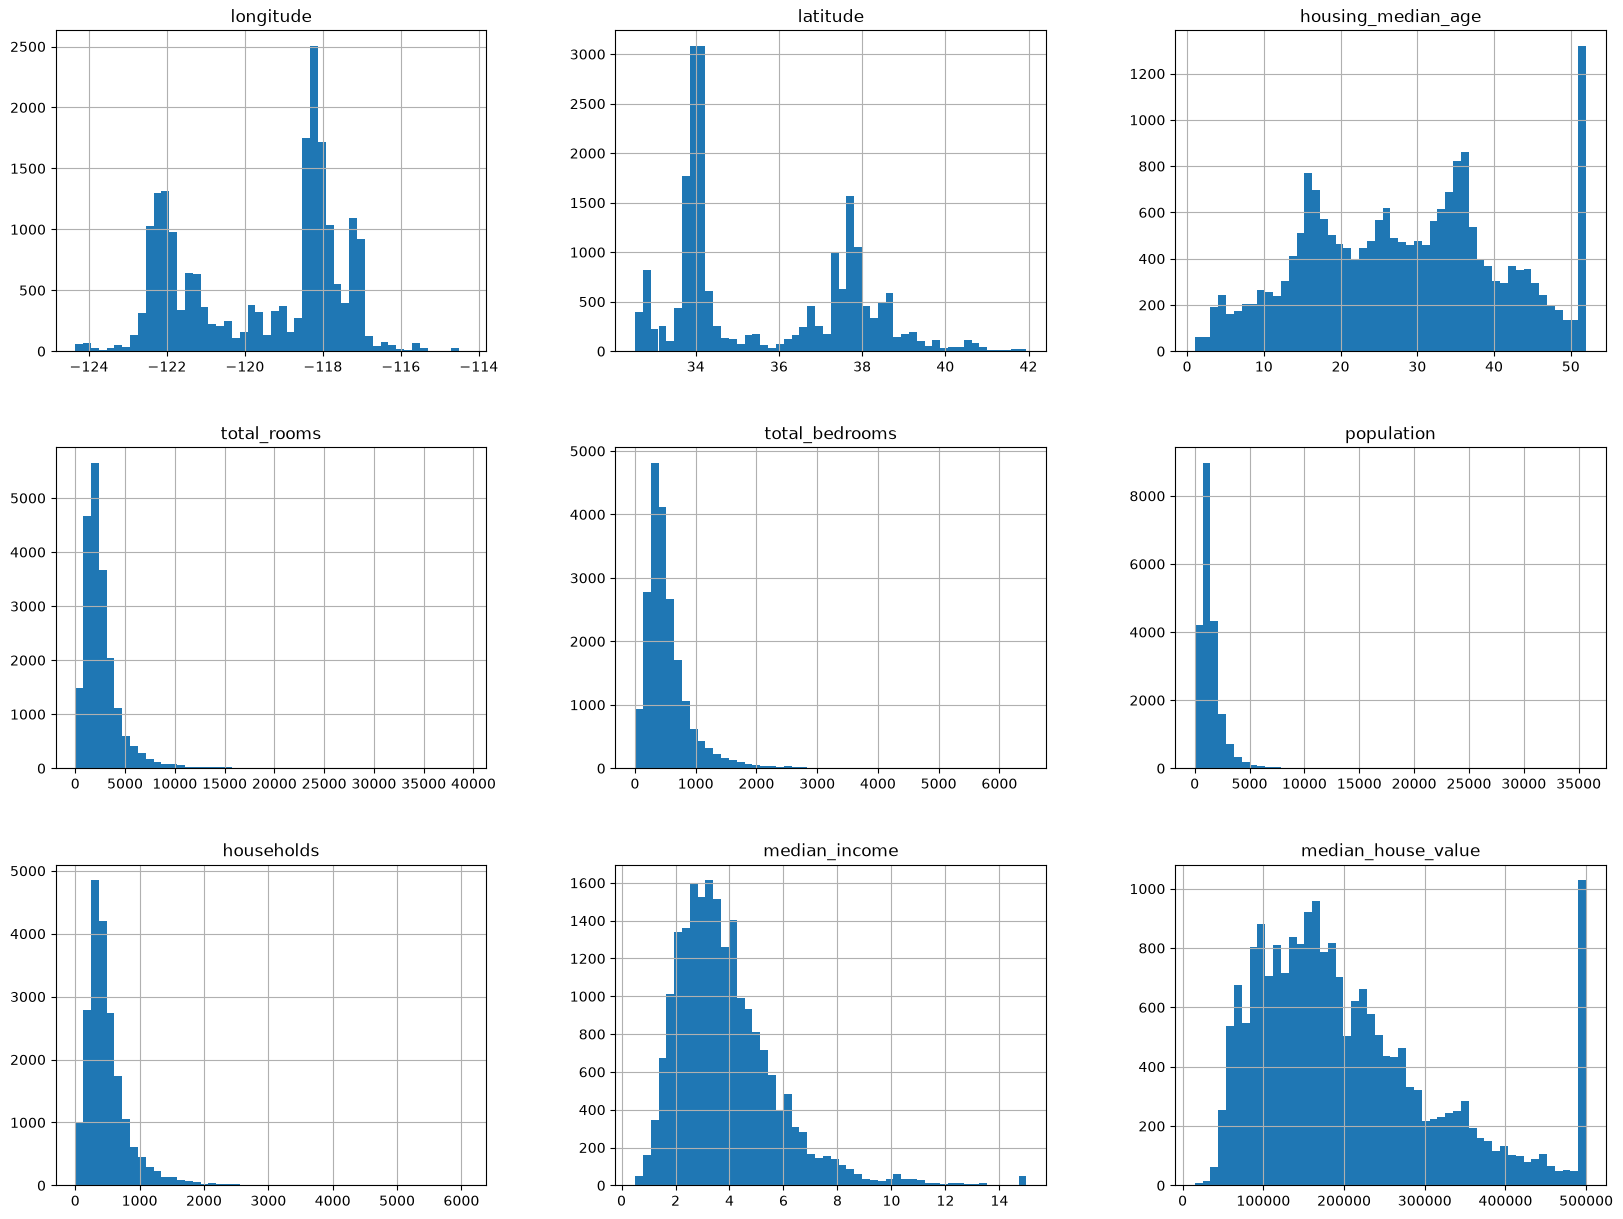

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()

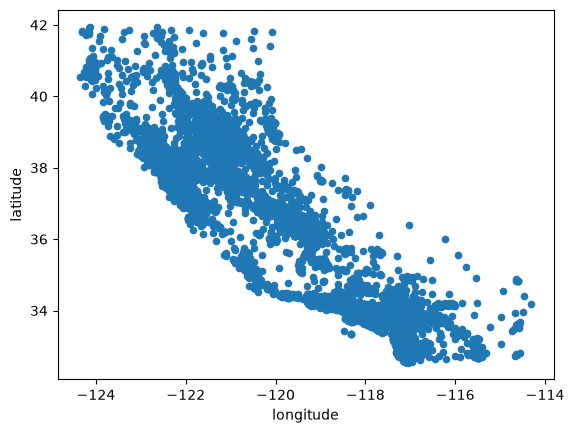

In [50]:
housing.plot(kind="scatter", x="longitude", y="latitude")
plt.show()

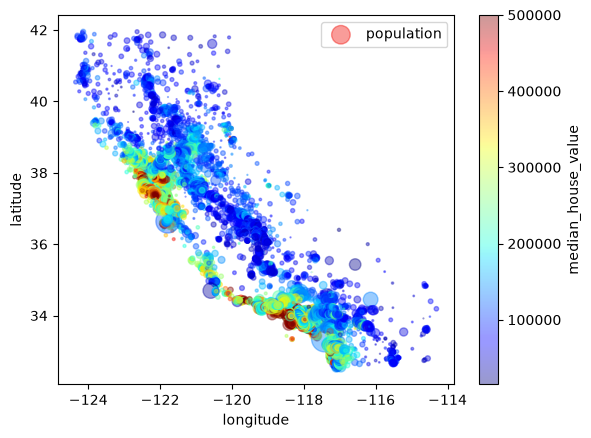

In [51]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
)

plt.show()

## 5. Looking for Correlations

Correlation analysis helps us investigate how numerical attributes are related to the target variable.

We calculate the correlation between each numerical attribute and `median_house_value`.

A correlation close to **1** indicates a strong positive relationship, while a correlation close to **-1** indicates a strong negative relationship. A value close to **0** indicates little linear correlation.

We also visualize the relationship between `median_income` and `median_house_value` because median income is expected to be an important predictor of house prices.

These observations help us identify potentially useful features before preparing the data for Machine Learning.

In [52]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

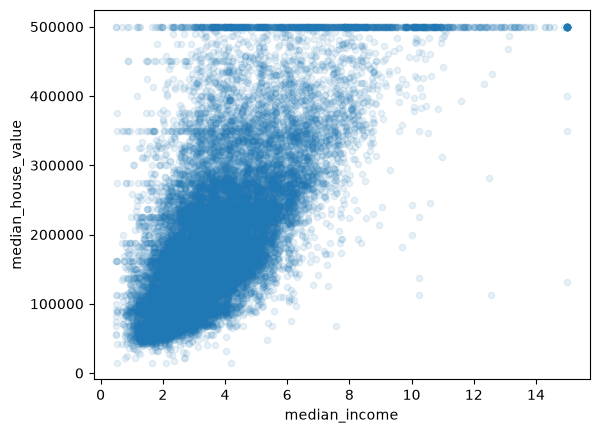

In [53]:
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1
)

plt.show()

## 6. Experimenting with Attribute Combinations

The original attributes do not always provide the most useful representation of the problem.

We can create new features by combining existing attributes.

In this project, we create:

- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

These features provide ratios that can be more informative than the original totals.

For example, the number of rooms alone does not tell us whether a district has many rooms because it contains many households. `rooms_per_household` provides a more meaningful measure of the average number of rooms available per household.

After creating these features, we examine the correlations again to determine whether they provide stronger relationships with `median_house_value`.

In [54]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]

housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

housing["population_per_household"] = housing["population"] / housing["households"]

In [55]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [56]:
import sys
print(sys.executable)

/home/justine/Desktop/ML/NILEAGI/REGRESSION/Summary notebook/env/bin/python


In [57]:
%%capture
%pip install scikit-learn

In [58]:
import sklearn
print(sklearn.__version__)

1.9.0


# 7. Create the Test Set

Before continuing with detailed data exploration and model development, we need to create a test set.

The test set must be kept separate from the training data so that we can evaluate the final model on data that it has never seen during training.

A simple random split can sometimes produce a test set that does not accurately represent the overall dataset.

Therefore, we first create a basic training/test split and then improve the approach using stratified sampling based on median income.

In [59]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

## 8. Create a Test Set Using Stratified Sampling

A Machine Learning model must eventually be evaluated on data that it has not seen during training.

Therefore, we separate the dataset into:

- a **training set**, used to train the models
- a **test set**, kept aside for the final evaluation


In [60]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3., 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

In [61]:
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [62]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [63]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [64]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [65]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# 9. Explore the Training Set

The test set has now been separated and must remain untouched until the final evaluation.

From this point onward, we perform our detailed exploration using only the training set.

This prevents information from the test set from influencing our decisions during model development.

We again examine geographic distributions, population and house-value relationships, correlations, scatter matrices, and the relationship between median income and median house value.

In [66]:
housing = strat_train_set.copy()

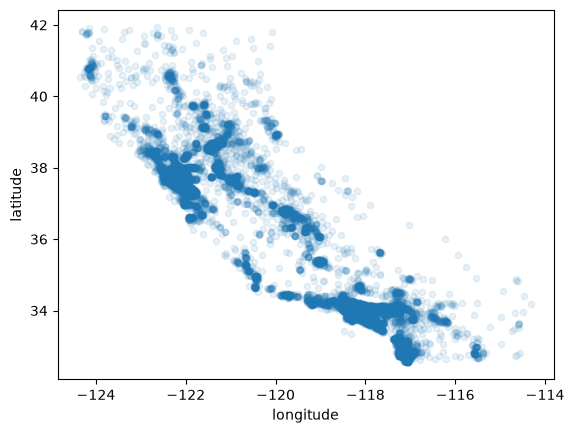

In [67]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.1
)

plt.show()

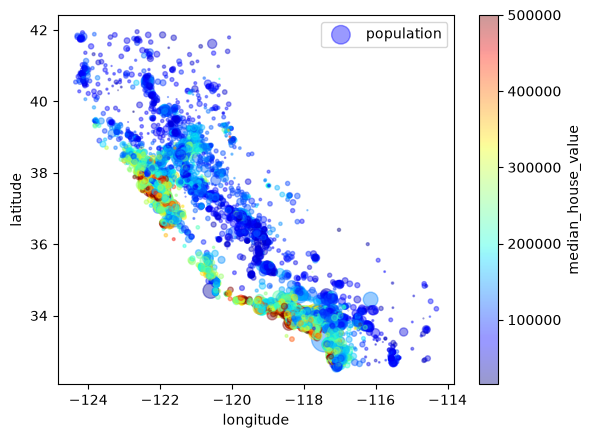

In [68]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
)

plt.show()

In [69]:
corr_matrix = housing.corr(numeric_only=True)

In [70]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

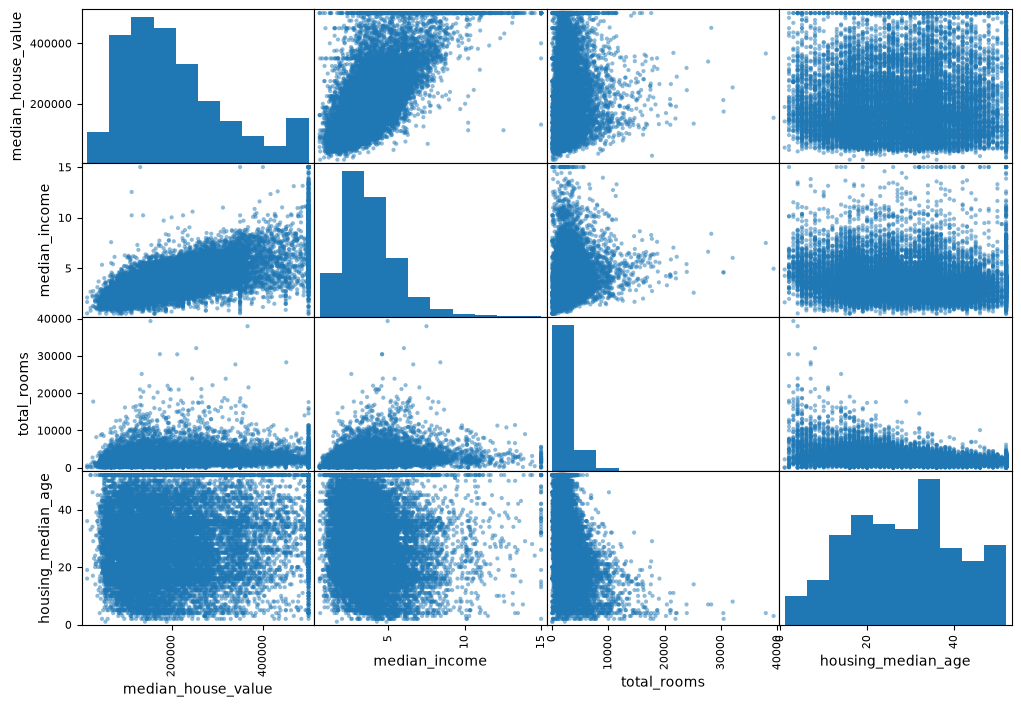

In [71]:
from pandas.plotting import scatter_matrix

attributes = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "housing_median_age"
]

scatter_matrix(housing[attributes], figsize=(12, 8))

plt.show()


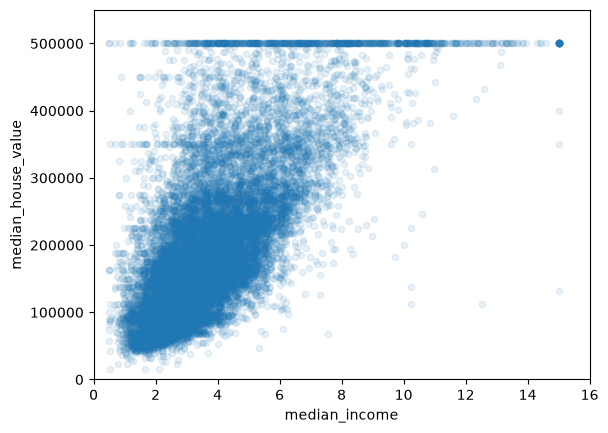

In [72]:
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1
)

plt.axis([0, 16, 0, 550000])

plt.show()

# 10. Prepare the Data for Machine Learning

The data must be transformed into a form that Machine Learning algorithms can process.

We separate the predictors from the target variable.

The target variable is:

`median_house_value`

The remaining columns are used as predictors.

During preprocessing, we will:

1. Handle missing numerical values.
2. Transform categorical attributes into numerical values.
3. Scale numerical features.
4. Combine these transformations into a preprocessing pipeline.

The preprocessing steps are fitted using the training data so that information from the test set does not leak into the training process.


In [73]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [74]:
housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 16512 non-null  float64
 1   latitude                  16512 non-null  float64
 2   housing_median_age        16512 non-null  float64
 3   total_rooms               16512 non-null  float64
 4   total_bedrooms            16354 non-null  float64
 5   population                16512 non-null  float64
 6   households                16512 non-null  float64
 7   median_income             16512 non-null  float64
 8   ocean_proximity           16512 non-null  str    
 9   rooms_per_household       16512 non-null  float64
 10  bedrooms_per_room         16354 non-null  float64
 11  population_per_household  16512 non-null  float64
dtypes: float64(11), str(1)
memory usage: 1.6 MB


## 11. Handling Missing Values

The `total_bedrooms` attribute contains missing values.

Most Machine Learning algorithms cannot work directly with missing numerical values, so we need to replace them.

We use Scikit-Learn's `SimpleImputer` with the `median` strategy.

The imputer calculates the median of each numerical attribute using the training data and uses those median values to replace missing values.

The imputation strategy is learned from the training data and then reused when transforming other datasets.

In [75]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [76]:
housing_num = housing.select_dtypes(include=["number"])

In [77]:
imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['longitude','latitude','housing_median_age',...,'rooms_per_household', 'bedrooms_per_room','population_per_household']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](11,)","[-118.51, 34.26, 29. ,..., 5.23, 0.2 , 2.82]"


In [78]:
imputer.statistics_

array([-1.18510000e+02,  3.42600000e+01,  2.90000000e+01,  2.11900000e+03,
        4.33000000e+02,  1.16400000e+03,  4.08000000e+02,  3.54155000e+00,
        5.23234164e+00,  2.03027043e-01,  2.81766108e+00])

In [79]:
for column, median in zip(housing_num.columns, imputer.statistics_):
    print(column, "→", median)

longitude → -118.51
latitude → 34.26
housing_median_age → 29.0
total_rooms → 2119.0
total_bedrooms → 433.0
population → 1164.0
households → 408.0
median_income → 3.54155
rooms_per_household → 5.232341640765675
bedrooms_per_room → 0.20302704317273024
population_per_household → 2.8176610834960165


In [80]:
X = imputer.transform(housing_num)

In [81]:
housing_tr = pd.DataFrame(
    X,
    columns=housing_num.columns,
    index=housing_num.index
)

In [82]:
housing_tr.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 16512 non-null  float64
 1   latitude                  16512 non-null  float64
 2   housing_median_age        16512 non-null  float64
 3   total_rooms               16512 non-null  float64
 4   total_bedrooms            16512 non-null  float64
 5   population                16512 non-null  float64
 6   households                16512 non-null  float64
 7   median_income             16512 non-null  float64
 8   rooms_per_household       16512 non-null  float64
 9   bedrooms_per_room         16512 non-null  float64
 10  population_per_household  16512 non-null  float64
dtypes: float64(11)
memory usage: 1.5 MB


## 12. Handling Text and Categorical Attributes

The `ocean_proximity` attribute contains categorical text values rather than numerical values.

Machine Learning algorithms generally require numerical input, so these categories must be converted into numerical features.

We use **One-Hot Encoding**.

One-hot encoding creates a separate binary feature for each category. This allows the model to use the information contained in `ocean_proximity` without incorrectly assuming that the categories have a numerical order.

In [83]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: count, dtype: int64

In [84]:
from sklearn.preprocessing import OneHotEncoder

In [85]:
cat_encoder = OneHotEncoder()

In [86]:
housing_cat = housing[["ocean_proximity"]]
cat_encoder.fit(housing_cat)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent

In [87]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [88]:
housing_cat_1hot = cat_encoder.transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [89]:
cat_encoder.get_feature_names_out(["ocean_proximity"])

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

## 13. Build a Transformation Pipeline

Performing each preprocessing step manually can lead to repeated code and inconsistencies.

Scikit-Learn provides `Pipeline` so that several transformations can be combined into a single sequence.

For the numerical attributes, our pipeline performs:

1. Missing-value imputation using the median.
2. Feature scaling using `StandardScaler`.

We then use `ColumnTransformer` to apply the numerical pipeline to numerical attributes and One-Hot Encoding to the categorical attribute.

The result is a single `full_pipeline` that can transform the housing data consistently.

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [91]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])

In [92]:
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [93]:
housing_num_tr.shape

(16512, 11)

In [94]:
from sklearn.compose import ColumnTransformer

In [95]:
num_attribs = list(housing_num.columns)
cat_attribs = ["ocean_proximity"]

In [96]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

In [97]:
housing_prepared = full_pipeline.fit_transform(housing)

In [98]:
housing_prepared.shape

(16512, 16)

# 14. Select and Train a Machine Learning Model

The data is now prepared, so we can begin training Machine Learning models.

This is a **regression problem** because the target variable, `median_house_value`, is a continuous numerical value.

Rather than assuming that one algorithm will perform best, we train several models and compare their performance.

We begin with Linear Regression, then test a Decision Tree Regressor and a Random Forest Regressor.

## 15. Linear Regression

Linear Regression provides a simple baseline model.

It attempts to predict the target by learning a linear relationship between the input features and `median_house_value`.

We first train the model on the prepared training data and then make predictions on a small sample.

We evaluate the model using **Root Mean Square Error (RMSE)**.

A lower RMSE indicates better predictive performance.

In [99]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [100]:
lin_reg.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-56046.34,-56657.83, 13931.57,...,105745.07,-22255.1 ,-14160.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.355e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[253.97,187.17,175.39,..., 16.32, 1.58, 0. ]"


In [101]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [ 83648.54287152 305815.0882093  150013.37994426 188096.42566946
 241840.13952577]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [102]:
from sklearn.metrics import mean_squared_error

In [103]:
housing_predictions = lin_reg.predict(housing_prepared)

lin_mse = mean_squared_error(housing_labels, housing_predictions)

lin_rmse = np.sqrt(lin_mse)

lin_rmse

np.float64(68160.92435491859)

## 16. Decision Tree Regression

A Decision Tree Regressor can model nonlinear relationships by repeatedly splitting the data according to feature values.

It is more flexible than Linear Regression and can capture relationships that a simple linear model may miss.

However, a Decision Tree can easily overfit the training data, so we need to compare its training performance with its performance on unseen data using cross-validation.

In [104]:
from sklearn.tree import DecisionTreeRegressor

In [105]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [106]:
housing_predictions = tree_reg.predict(housing_prepared)

In [107]:
tree_mse = mean_squared_error(housing_labels, housing_predictions)

In [108]:
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

# 17. Better Evaluation Using Cross-Validation

Evaluating a model only on the training data can give a misleading impression of performance because a model may memorize the training examples.

To obtain a more reliable estimate, we use **K-fold cross-validation**.

The training set is divided into several folds. The model is trained on some folds and evaluated on the remaining fold. This process is repeated so that every fold is used for validation.

We calculate RMSE for each fold and then examine:

- the individual RMSE scores,
- the mean RMSE,
- and the standard deviation.

Cross-validation gives us a better understanding of how well the model is likely to generalize to unseen data.

In [109]:
from sklearn.model_selection import cross_val_score

In [110]:
scores = cross_val_score(
    tree_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

In [111]:
np.sqrt(-scores)

array([72634.11482714, 70417.41375688, 66445.26367871, 73096.25142031,
       68458.48098974, 74952.30726479, 71812.92001841, 72304.29994705,
       68265.83261163, 70190.01324069])

In [112]:
np.mean(np.sqrt(-scores))

np.float64(70857.68977553424)

In [113]:
np.std(np.sqrt(-scores))

np.float64(2460.100561636933)

In [114]:
lin_scores = cross_val_score(
    lin_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)


In [115]:
np.sqrt(-lin_scores)

array([71181.95098096, 63825.56512744, 67741.07241029, 68256.29685279,
       66711.2271161 , 72240.73664717, 69981.07976999, 68438.51358706,
       65946.92067317, 70073.85093767])

In [116]:
np.mean(np.sqrt(-lin_scores))

np.float64(68439.72141026422)

In [117]:
np.std(np.sqrt(-lin_scores))

np.float64(2408.892846297472)

# 18. Random Forest Regression

Random Forest is an ensemble learning method that combines many Decision Trees.

Instead of depending on a single Decision Tree, Random Forest builds multiple trees and combines their predictions.

This generally makes the model more robust and powerful than an individual Decision Tree.

We train a Random Forest Regressor, calculate its training error, and then use cross-validation to obtain a more realistic estimate of its performance.

In [118]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()

In [119]:
forest_reg.fit(housing_prepared, housing_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [120]:
forest_predictions = forest_reg.predict(housing_prepared)

In [121]:
forest_mse = mean_squared_error(housing_labels, forest_predictions)

In [122]:
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(18786.87803874936)

In [123]:
forest_scores = cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

In [124]:
np.sqrt(-forest_scores)

array([51189.06992628, 49315.61116237, 46168.70397436, 52362.774691  ,
       47621.98678683, 51747.91852858, 52250.82933647, 49644.73009491,
       48904.80713515, 53813.38780054])

In [125]:
np.mean(np.sqrt(-forest_scores))

np.float64(50301.98194364902)

In [126]:
np.std(np.sqrt(-forest_scores))

np.float64(2255.5679387858963)

# 19. Fine-Tune the Best Model

After comparing the models, Random Forest provides strong performance.

However, Random Forest has hyperparameters that control how the forest is constructed.

Instead of choosing these hyperparameters manually, we use **GridSearchCV**.

GridSearchCV evaluates different combinations of hyperparameter values using cross-validation and identifies the combination that produces the best validation performance.

In [127]:
from sklearn.model_selection import GridSearchCV

In [128]:
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

In [129]:
grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True
)

In [130]:
grid_search.fit(housing_prepared, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will onl

## 20. Best Hyperparameters

After testing the specified combinations, `GridSearchCV` identifies the hyperparameter combination that produced the best cross-validation performance.

The selected model configuration can then be used as our final candidate model.

We also inspect the best estimator and its cross-validation RMSE to understand the improvement obtained through fine-tuning.

In [131]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [132]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number 

In [133]:
np.sqrt(-grid_search.best_score_)

np.float64(50106.41660314244)

# 21. Analyze the Best Model

After finding the best Random Forest model, we can examine its **feature importances**.

Feature importance provides an indication of which features were most useful to the model when making predictions.

Because the preprocessing pipeline creates additional features, we first reconstruct the complete list of feature names, including:

- original numerical attributes,
- engineered attributes,
- and one-hot encoded categorical attributes.

We then match these names with the feature importance values and sort them to identify the most influential features.

In [134]:
feature_importances = grid_search.best_estimator_.feature_importances_

In [135]:
extra_attribs = ["rooms_per_household", "population_per_household", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.get_feature_names_out(["ocean_proximity"]))

In [136]:
attributes = num_attribs + cat_one_hot_attribs

In [137]:
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.3790581821628496), 'median_income'),
 (np.float64(0.1531055086417315), 'ocean_proximity_INLAND'),
 (np.float64(0.11071507020111675), 'population_per_household'),
 (np.float64(0.07280365011847387), 'longitude'),
 (np.float64(0.06523746986493476), 'latitude'),
 (np.float64(0.057621793162396864), 'bedrooms_per_room'),
 (np.float64(0.04977666049452448), 'rooms_per_household'),
 (np.float64(0.040713831611491634), 'housing_median_age'),
 (np.float64(0.014857320678544214), 'total_rooms'),
 (np.float64(0.014634610502098895), 'population'),
 (np.float64(0.01429244059655659), 'total_bedrooms'),
 (np.float64(0.013992959637120009), 'households'),
 (np.float64(0.008396788943720878), 'ocean_proximity_<1H OCEAN'),
 (np.float64(0.0030152322696390082), 'ocean_proximity_NEAR OCEAN'),
 (np.float64(0.001667228918294823), 'ocean_proximity_NEAR BAY'),
 (np.float64(0.00011125219650600687), 'ocean_proximity_ISLAND')]

# 22. Evaluate the Final Model on the Test Set

We now select the best estimator returned by `GridSearchCV` as our final model.

The test set has been kept separate from the training and model-selection process.

We prepare the test features using the **same preprocessing pipeline** that was fitted on the training data.

The final model then predicts the house values for the test set, and we calculate the final RMSE.

This final test score provides our estimate of how well the trained system generalizes to previously unseen data.

In [138]:
final_model = grid_search.best_estimator_

In [139]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

In [140]:
X_test_prepared = full_pipeline.transform(X_test)

In [141]:
final_predictions = final_model.predict(X_test_prepared)

In [142]:
final_mse = mean_squared_error(y_test, final_predictions)

final_rmse = np.sqrt(final_mse)

final_rmse

np.float64(47933.04883985608)

# 23. Save the Trained Model and Preprocessing Pipeline

Training a Machine Learning model can take time, so we save the final solution to disk instead of retraining it every time we want to use it.

We use the `joblib` library to save:

- the trained Random Forest model
- the complete preprocessing pipeline

The files are saved as:

- `california_housing_model.pkl`
- `california_housing_pipeline.pkl`

Saving the preprocessing pipeline is important because new data must be transformed in exactly the same way as the training data before it is passed to the model.

In [143]:
import joblib

joblib.dump(final_model, "california_housing_model.pkl")

['california_housing_model.pkl']

In [144]:
joblib.dump(full_pipeline, "california_housing_pipeline.pkl")

['california_housing_pipeline.pkl']

## 24. Verify the Saved Files

Finally, we check the contents of the current working directory to confirm that the trained model and preprocessing pipeline have been saved successfully.

These files allow us to reuse the trained Machine Learning solution later without retraining it from scratch.

In [145]:
import os

print(os.listdir())

['housing.ipynb', 'california_housing_pipeline.pkl', 'california_housing_model.pkl', 'datasets', 'env']


In [146]:
import sys
print(sys.executable)

/home/justine/Desktop/ML/NILEAGI/REGRESSION/Summary notebook/env/bin/python


In [147]:
import joblib

In [148]:
model = joblib.load("california_housing_model.pkl")
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number 

In [149]:
predictions = model.predict(X_test_prepared)
predictions[:5]

array([476944.06666667, 226570.06666667, 216143.33333333, 175276.66666667,
       251050.        ])

# 25. Launch, Monitor, and Maintain the System

A Machine Learning project does not end when the model has been trained and evaluated.

In a real-world application, the model must be deployed so that it can make predictions on new data.

After deployment, the system should be monitored because the real-world data may change over time. Changes in the data distribution can cause the model's performance to decrease.

A Machine Learning system therefore requires continuous maintenance:

**Train → Evaluate → Deploy → Monitor → Maintain → Retrain when necessary**

If new data becomes available or the model's performance decreases, the model can be retrained and evaluated again before deploying the updated version.